## 1. Install Libraries

In [1]:
!pip install -q tensorflow scikit-learn imbalanced-learn xgboost gradio wordcloud nltk

## 2. Imports

In [2]:
import re
import string
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils import resample
from imblearn.over_sampling import RandomOverSampler
import xgboost as xgb
import joblib

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 3. Upload Dataset

In [3]:
# ── Colab: upload via Files panel or use the path below ──────────────────────
# from google.colab import files
# uploaded = files.upload()   # pick your CSV

DATASET_PATH = "Dataset---Hate-Speech-Detection-using-Deep-Learning.csv"

df = pd.read_csv(DATASET_PATH)
print("Shape:", df.shape)
df.head()

Shape: (24783, 2)


,class,tweet
0,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   class   24783 non-null  int64 
 1   tweet   24783 non-null  object
dtypes: int64(1), object(1)
memory usage: 387.4+ KB

class
1    19190
2     4163
0     1430
Name: count, dtype: int64


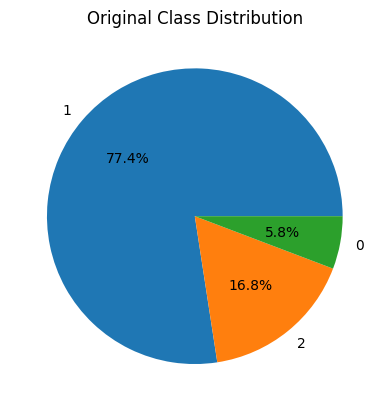

In [4]:
df.info()
print()
print(df['class'].value_counts())

plt.pie(df['class'].value_counts().values,
        labels=df['class'].value_counts().index,
        autopct='%1.1f%%')
plt.title("Original Class Distribution")
plt.show()

## 4. Data Cleaning

In [5]:
lemmatizer = WordNetLemmatizer()
STOP_WORDS  = set(stopwords.words('english'))

def clean_text(text: str) -> str:
    # Lower-case
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Stopword removal + lemmatization
    words = [lemmatizer.lemmatize(w)
             for w in text.split() if w not in STOP_WORDS]
    return " ".join(words)

df['tweet'] = df['tweet'].astype(str).apply(clean_text)
df.head()

,class,tweet
0,2,rt mayasolovely woman shouldnt complain cleani...
1,1,rt mleew17 boy dat coldtyga dwn bad cuffin dat...
2,1,rt urkindofbrand dawg rt 80sbaby4life ever fuc...
3,1,rt cganderson vivabased look like tranny
4,1,rt shenikaroberts shit hear might true might f...


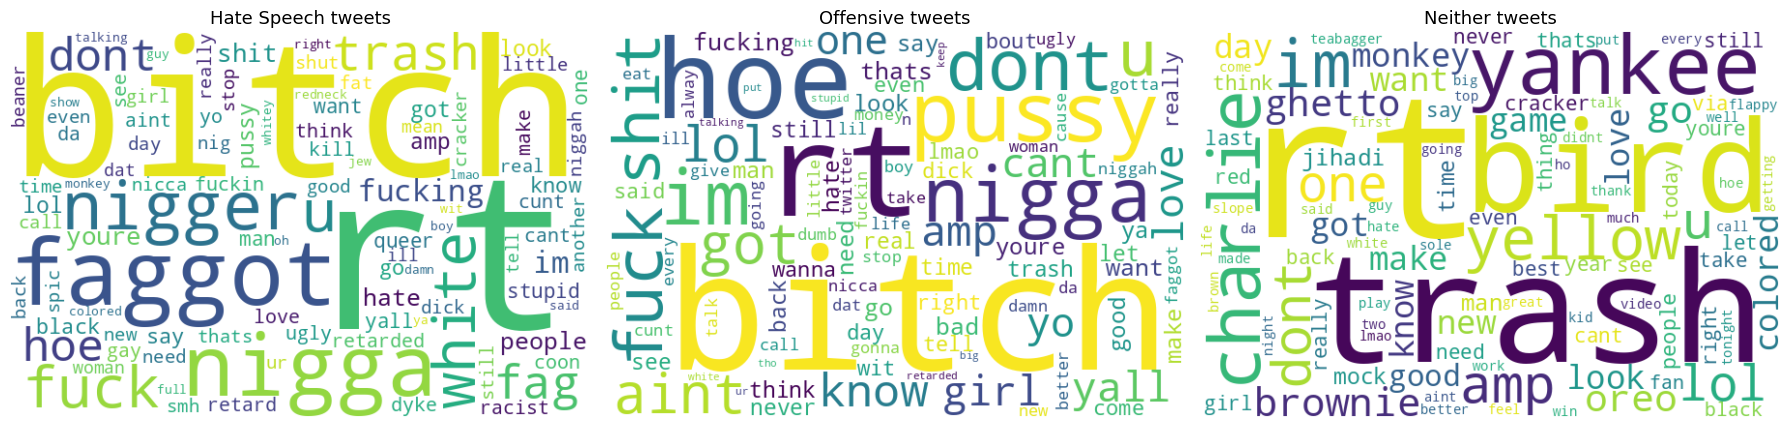

In [6]:
# ── Word-cloud for each class ─────────────────────────────────────────────────
label_names = {0: 'Hate Speech', 1: 'Offensive', 2: 'Neither'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for cls, ax in zip([0, 1, 2], axes):
    text = " ".join(df[df['class'] == cls]['tweet'])
    wc = WordCloud(max_words=100, width=600, height=400,
                   background_color="white", collocations=False).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label_names[cls]} tweets', fontsize=13)
plt.tight_layout()
plt.show()

class
2    4163
1    4163
0    4163
Name: count, dtype: int64


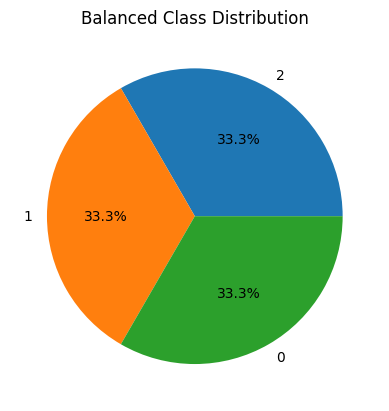

In [7]:
# ── Balance classes via resampling ────────────────────────────────────────────
TARGET = 4163   # size of class 2 (medium class)

c0_bal = resample(df[df['class']==0], replace=True,  n_samples=TARGET, random_state=42)
c1_bal = resample(df[df['class']==1], replace=False, n_samples=TARGET, random_state=42)
c2_bal = resample(df[df['class']==2], replace=True,  n_samples=TARGET, random_state=42)

balanced_df = pd.concat([c0_bal, c1_bal, c2_bal]).sample(frac=1, random_state=42).reset_index(drop=True)

print(balanced_df['class'].value_counts())
plt.pie(balanced_df['class'].value_counts().values,
        labels=balanced_df['class'].value_counts().index,
        autopct='%1.1f%%')
plt.title("Balanced Class Distribution")
plt.show()

## 5. Train / Test Split

In [8]:
X = balanced_df['tweet']
y = balanced_df['class']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=22, stratify=y
)

print(f"Train size : {len(X_train)}")
print(f"Val   size : {len(X_val)}")

Train size : 9991
Val   size : 2498


## 6. Tokenizer

In [9]:
MAX_WORDS = 10_000
MAX_LEN   = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

print("Vocabulary size:", len(tokenizer.word_index))

Vocabulary size: 15823


## 7. Padding

In [10]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post')

print("X_train_pad shape:", X_train_pad.shape)
print("X_val_pad   shape:", X_val_pad.shape)

X_train_pad shape: (9991, 100)
X_val_pad   shape: (2498, 100)


## 8. Build BiLSTM Model

In [11]:
bilstm_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

bilstm_model.compile(
    optimizer='adam',
    loss=SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

bilstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 9. Train Model

In [12]:
callbacks = [
    EarlyStopping(patience=3, monitor='val_accuracy', restore_best_weights=True),
    ReduceLROnPlateau(patience=2, monitor='val_loss', factor=0.5, verbose=1)
]

history = bilstm_model.fit(
    X_train_pad, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_pad, y_val),
    callbacks=callbacks
)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 86s 218ms/step - accuracy: 0.7710 - loss: 0.5464 - val_accuracy: 0.8803 - val_loss: 0.3557 - learning_rate: 0.0010
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 217ms/step - accuracy: 0.9369 - loss: 0.2015 - val_accuracy: 0.9075 - val_loss: 0.2684 - learning_rate: 0.0010
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 79s 207ms/step - accuracy: 0.9677 - loss: 0.1145 - val_accuracy: 0.9163 - val_loss: 0.2644 - learning_rate: 0.0010
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 64s 204ms/step - accuracy: 0.9801 - loss: 0.0733 - val_accuracy: 0.9155 - val_loss: 0.2752 - learning_rate: 0.0010
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9876 - loss: 0.0532
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 204ms/step - accuracy: 0.9828 - loss: 0.0610 - val_accuracy: 0.9183 - val_loss: 0.3159 - learning_rate: 0.0010
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 204ms/step - accuracy: 0.990

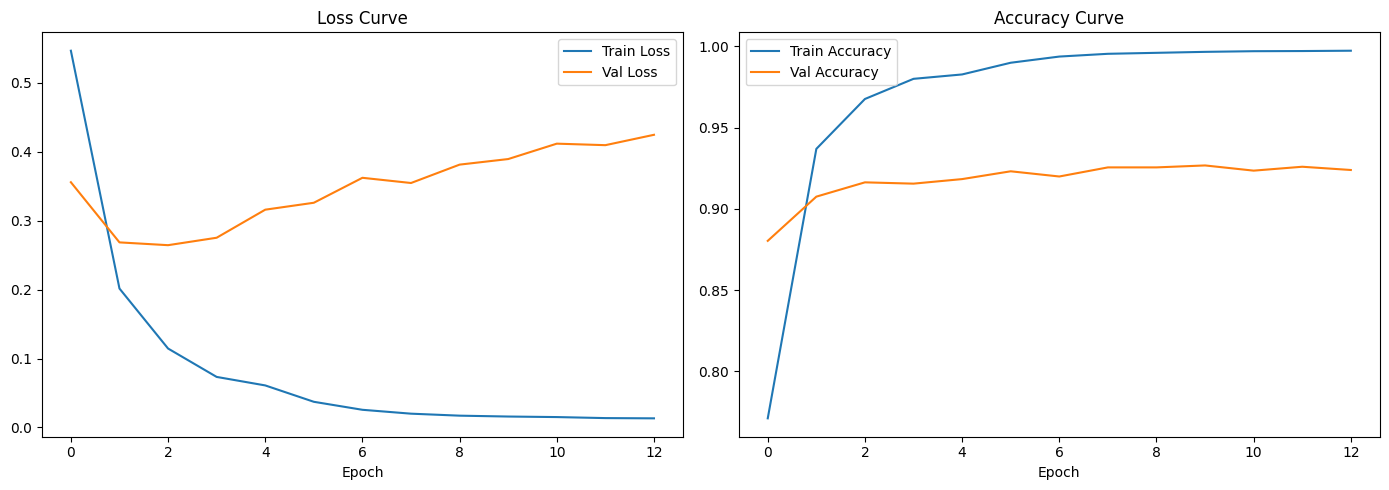

In [13]:
# ── Training curves ───────────────────────────────────────────────────────────
history_df = pd.DataFrame(history.history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_df['loss'],     label='Train Loss')
ax1.plot(history_df['val_loss'], label='Val Loss')
ax1.set_title('Loss Curve'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(history_df['accuracy'],     label='Train Accuracy')
ax2.plot(history_df['val_accuracy'], label='Val Accuracy')
ax2.set_title('Accuracy Curve'); ax2.set_xlabel('Epoch'); ax2.legend()

plt.tight_layout()
plt.show()

## 10. Evaluation – BiLSTM

In [14]:
val_loss, val_acc = bilstm_model.evaluate(X_val_pad, y_val, verbose=0)
print(f"Validation Loss     : {val_loss:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")

y_pred_bilstm = np.argmax(bilstm_model.predict(X_val_pad), axis=1)
print()
print(classification_report(y_val, y_pred_bilstm,
                             target_names=['Hate Speech','Offensive','Neither']))

Validation Loss     : 0.3893
Validation Accuracy : 0.9267
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step

              precision    recall  f1-score   support

 Hate Speech       0.93      0.95      0.94       833
   Offensive       0.91      0.89      0.90       833
     Neither       0.93      0.95      0.94       832

    accuracy                           0.93      2498
   macro avg       0.93      0.93      0.93      2498
weighted avg       0.93      0.93      0.93      2498



## 11. Save Model & Tokenizer

In [15]:
bilstm_model.save("hate_speech_bilstm.h5")

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Model and tokenizer saved.")

Model and tokenizer saved.


## 12. BiLSTM Prediction Function

In [16]:
LABEL_MAP = {0: 'Hate Speech', 1: 'Offensive', 2: 'Neither'}

def predict_bilstm(text: str):
    """Return (label, probability_array) for a single string."""
    cleaned = clean_text(text)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    probs   = bilstm_model.predict(padded, verbose=0)[0]
    label   = LABEL_MAP[int(np.argmax(probs))]
    return label, probs

# Quick test
label, probs = predict_bilstm("I am in love with you")
print(f"Label: {label}  |  Probabilities: {probs}")

Label: Neither  |  Probabilities: [0.00161792 0.00114074 0.9972414 ]


## 13. Logistic Regression

In [17]:
# Use the original (unbalanced) df with the same 80/20 split for fair comparison
X_lr = df['tweet']
y_lr = df['class']

X_train_lr, X_val_lr, y_train_lr, y_val_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42, stratify=y_lr
)

tfidf_lr = TfidfVectorizer(stop_words='english', max_features=10_000, ngram_range=(1, 2))
X_train_lr_tfidf = tfidf_lr.fit_transform(X_train_lr)
X_val_lr_tfidf   = tfidf_lr.transform(X_val_lr)

logreg_model = LogisticRegression(max_iter=2000, random_state=42)
logreg_model.fit(X_train_lr_tfidf, y_train_lr)

y_pred_lr = logreg_model.predict(X_val_lr_tfidf)
lr_acc    = accuracy_score(y_val_lr, y_pred_lr)

print(f"Logistic Regression Accuracy: {lr_acc:.4f}")
print()
print(classification_report(y_val_lr, y_pred_lr,
                             target_names=['Hate Speech','Offensive','Neither']))

Logistic Regression Accuracy: 0.8949

              precision    recall  f1-score   support

 Hate Speech       0.65      0.17      0.27       286
   Offensive       0.91      0.97      0.94      3838
     Neither       0.85      0.82      0.83       833

    accuracy                           0.89      4957
   macro avg       0.80      0.65      0.68      4957
weighted avg       0.88      0.89      0.88      4957



In [18]:
def predict_logreg(text: str) -> str:
    vec  = tfidf_lr.transform([clean_text(text)])
    pred = logreg_model.predict(vec)[0]
    return LABEL_MAP[pred]

print(predict_logreg("You are braindead"))

Offensive


## 14. XGBoost

In [19]:
tfidf_xgb = TfidfVectorizer(stop_words='english', max_features=5_000)
X_train_xgb = tfidf_xgb.fit_transform(X_train_lr)
X_val_xgb   = tfidf_xgb.transform(X_val_lr)

xgb_model = xgb.XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    max_depth=6,
    learning_rate=0.2,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    random_state=42
)
xgb_model.fit(X_train_xgb, y_train_lr)

y_pred_xgb = xgb_model.predict(X_val_xgb)
xgb_acc    = accuracy_score(y_val_lr, y_pred_xgb)

print(f"XGBoost Accuracy: {xgb_acc:.4f}")
print()
print(classification_report(y_val_lr, y_pred_xgb,
                             target_names=['Hate Speech','Offensive','Neither']))

joblib.dump(xgb_model,  "xgb_model.pkl")
joblib.dump(tfidf_xgb,  "tfidf_xgb.pkl")
print("XGBoost model and vectorizer saved.")

XGBoost Accuracy: 0.8951

              precision    recall  f1-score   support

 Hate Speech       0.56      0.26      0.36       286
   Offensive       0.93      0.94      0.94      3838
     Neither       0.79      0.91      0.84       833

    accuracy                           0.90      4957
   macro avg       0.76      0.70      0.71      4957
weighted avg       0.89      0.90      0.89      4957

XGBoost model and vectorizer saved.


In [20]:
def predict_xgb(text: str) -> str:
    vec  = tfidf_xgb.transform([clean_text(text)])
    pred = xgb_model.predict(vec)[0]
    return LABEL_MAP[int(pred)]

print(predict_xgb("I hate your voice"))

Neither


## 15. Compare Models

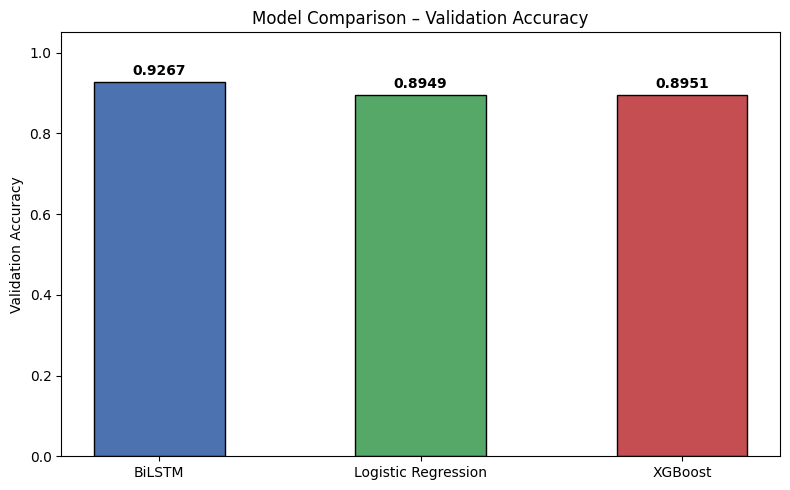

In [21]:
# ── Bar chart of validation accuracies ───────────────────────────────────────
model_names = ['BiLSTM', 'Logistic Regression', 'XGBoost']
accuracies  = [val_acc, lr_acc, xgb_acc]

colors = ['#4C72B0', '#55A868', '#C44E52']
plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black', width=0.5)
plt.ylim(0, 1.05)
plt.ylabel('Validation Accuracy')
plt.title('Model Comparison – Validation Accuracy')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# ── Side-by-side predictions for a few test sentences ────────────────────────
def compare_models(text: str):
    bl_label, bl_probs = predict_bilstm(text)
    lr_label           = predict_logreg(text)
    xb_label           = predict_xgb(text)

    print(f"Input : {text}")
    print(f"  BiLSTM              → {bl_label}  (probs: {np.round(bl_probs,3)})")
    print(f"  Logistic Regression → {lr_label}")
    print(f"  XGBoost             → {xb_label}")
    print()

test_sentences = [
    "I hate people like you",
    "I am in love with you",
    "You are absolutely disgusting",
]
for s in test_sentences:
    compare_models(s)

Input : I hate people like you
  BiLSTM              → Hate Speech  (probs: [0.961 0.011 0.029])
  Logistic Regression → Offensive
  XGBoost             → Hate Speech

Input : I am in love with you
  BiLSTM              → Neither  (probs: [0.002 0.001 0.997])
  Logistic Regression → Offensive
  XGBoost             → Neither

Input : You are absolutely disgusting
  BiLSTM              → Neither  (probs: [0.002 0.001 0.997])
  Logistic Regression → Offensive
  XGBoost             → Neither



## 16. Gradio Interface

In [23]:
!pip install -q gradio

In [24]:
import gradio as gr

def gradio_predict(text: str) -> str:
    if not text.strip():
        return "Please enter some text."

    bl_label, bl_probs = predict_bilstm(text)
    lr_label           = predict_logreg(text)
    xb_label           = predict_xgb(text)

    icon = {"Hate Speech": "🚫", "Offensive": "⚠️", "Neither": "✅"}

    result = (
        f"**BiLSTM**              : {icon[bl_label]} {bl_label}\n"
        f"**Logistic Regression** : {icon[lr_label]} {lr_label}\n"
        f"**XGBoost**             : {icon[xb_label]} {xb_label}\n\n"
        f"BiLSTM confidence: {dict(zip(LABEL_MAP.values(), np.round(bl_probs, 3)))}"
    )
    return result

interface = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(lines=4, placeholder="Enter text here…", label="Input Text"),
    outputs=gr.Markdown(label="Predictions"),
    title="🚨 Hate Speech Detection System",
    description=(
        "Enter any text and compare predictions from three models:\n"
        "**BiLSTM** · **Logistic Regression** · **XGBoost**"
    ),
    theme="soft",
    examples=[
        ["I am in love with you"],
        ["You are braindead"],
        ["I hate people like you"],
    ]
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0bf92bd39882660ddb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
